# Extended Stzandardization Procedure of FartDB

These additional standarization steps are employed to investigate potential data leakage:

- removal of compounds with contradictory labels
- salt stripping
- reionization
- tautomer canonicalization
- removal of stereodescriptors


Removal of duplicates is changed from SMILES-based to InChiKeys.

In [31]:
import rdkit
from rdkit import Chem
from rdkit.Chem import rdmolops
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.Chem import SaltRemover
import pandas as pd
from rdkit import RDLogger
import swifter

RDLogger.DisableLog('rdApp.info')

In [32]:
fart0 = pd.read_csv("../dataset/fart_curated.csv")
len(fart0)

15025

In [33]:
### Identigy rows with contradictory taste labels
df_not = fart0[fart0["Original Labels"].apply(lambda x: "not" in x.lower() or "contra" in x.lower())]

print("Number of contradictory labels:", len(df_not))
# print(df_not["Original Labels"].values)
display(df_not[["Canonicalized SMILES", "Canonicalized Taste", "Original Labels"]])
df_not[["Original Labels"]].to_dict()

Number of contradictory labels: 17


,Canonicalized SMILES,Canonicalized Taste,Original Labels
12279,O=Cc1cccc2c1CCOC2=O,bitter,contradictory evidence: tasteless (metabolite ...
12295,COc1cc2ccc(=O)oc2c(O)c1O,sour,"Bitter (contradictory evidence): bitter, non b..."
12458,C=C1CCC2C(C)(COC3OC(CO)C(O)C(O)C3O)CCCC2(C)C1C...,bitter,Bitter (contradictory evidence): bitter (low e...
12525,O=C(CCCCC=Cc1ccc2c(c1)OCO2)N1CCCCC1,undefined,pungent; not pungent
12526,O=C(CCCCCCC=Cc1ccc2c(c1)OCO2)N1CCCCC1,undefined,pungent; not pungent
14396,CC=CC=CC=CCCC=CC(=O)NCC(C)(C)O,bitter,pungent (numbing); astringent; bitter; tastele...
14676,COC1CC(OC2C(C)OC(OC3C(C)OC(OC4CCC5(C)C(=CCC6C5...,sweet,sweet; not bitter
14677,COC1CC(OC2C(C)OC(OC3C(C)OC(OC4CCC5(C)C(=CCC6C5...,bitter,sweet; not bitter
14678,COC1CC(OC2C(C)OC(OC3C(C)OC(OC4CCC5(C)C(=CCC6C5...,sweet,sweet; not bitter
14679,COC1CC(OC2C(C)OC(OC3C(C)OC(OC4CCC5(C)C(=CCC6C5...,bitter,sweet; not bitter


{'Original Labels': {12279: 'contradictory evidence: tasteless (metabolite of a bitter tastant: swertiamarin); bitter',
  12295: 'Bitter (contradictory evidence): bitter, non bitter; sour;_qwyx Note: fraxetin is also the intestinal metabolite and aglycon of fraxin (fraxetin-8-O-glucoside), which is bitter',
  12458: 'Bitter (contradictory evidence): bitter (low evidence), non bitter',
  12525: 'pungent; not pungent',
  12526: 'pungent; not pungent',
  14396: 'pungent (numbing); astringent; bitter; tasteless (contradictory evidence)',
  14676: 'sweet; not bitter',
  14677: 'sweet; not bitter',
  14678: 'sweet; not bitter',
  14679: 'sweet; not bitter',
  14837: 'bitter (contradictory evidence): bitter, non bitter; sour; astringent, sweet (insufficient evidence)',
  14838: 'bitter (contradictory evidence): bitter, non bitter; sour; astringent, sweet (insufficient evidence)',
  14858: 'astringent; bitter (contradictory evidence): bitter, non bitter; sour; sweet',
  14859: 'astringent; bit

In [34]:
### Manually inspected these 5 entries and decided to remove them from the dataset
'''
{
    'Canonicalized SMILES': {
        12458: 'C=C1CCC2C(C)(COC3OC(CO)C(O)C(O)C3O)CCCC2(C)C1CCC1=CCOC1=O',
        14677: 'COC1CC(OC2C(C)OC(OC3C(C)OC(OC4CCC5(C)C(=CCC6C5CCC5(C)C6CC(OC6OC(COC7OC(CO)C(O)C(O)C7O)C(O)C(O)C6O)C5C(C)=O)C4)C(O)C3OC)CC2OC)OC(C)C1OC(=O)C=C(C)C',
        14679: 'COC1CC(OC2C(C)OC(OC3C(C)OC(OC4CCC5(C)C(=CCC6C5CCC5(C)C6CC(OC6OC(COC7OC(CO)C(O)C(O)C7OC7OC(CO)C(O)C(O)C7O)C(O)C(O)C6O)C5C(C)=O)C4)C(O)C3OC)CC2OC)OC(C)C1OC(=O)C=C(C)C',
        14861: 'O=C(O)c1ccc(O)cc1',
        14896: 'O=C(O)CCC(=O)O'
    },
    'Standardized SMILES': {
        12458: 'C=C1CCC2C(C)(COC3OC(CO)C(O)C(O)C3O)CCCC2(C)C1CCC1=CCOC1=O',
        14677: 'COC1CC(OC2C(C)OC(OC3C(C)OC(OC4CCC5(C)C(=CCC6C5CCC5(C)C6CC(OC6OC(COC7OC(CO)C(O)C(O)C7O)C(O)C(O)C6O)C5C(C)=O)C4)C(O)C3OC)CC2OC)OC(C)C1OC(=O)C=C(C)C',
        14679: 'COC1CC(OC2C(C)OC(OC3C(C)OC(OC4CCC5(C)C(=CCC6C5CCC5(C)C6CC(OC6OC(COC7OC(CO)C(O)C(O)C7OC7OC(CO)C(O)C(O)C7O)C(O)C(O)C6O)C5C(C)=O)C4)C(O)C3OC)CC2OC)OC(C)C1OC(=O)C=C(C)C',
        14861: 'O=C(O)c1ccc(O)cc1',
        14896: 'O=C(O)CCC(=O)O'
    },
    'Canonicalized Taste': {
        12458: 'bitter',
        14677: 'bitter',
        14679: 'bitter',
        14861: 'bitter',
        14896: 'bitter'
    },
}
'''
indexes_to_remove = [12458, 14677, 14679, 14861, 14896]

# remove the matching rows to df_remove
fart01 = fart0[~fart0.index.isin(indexes_to_remove)]

In [35]:
### Refined standardization function

x = rdMolStandardize.CleanupParameters()
x.maxTransforms = 100000
x.maxTautomers = 10000

salt_remover = SaltRemover.SaltRemover()
uncharger = rdMolStandardize.Uncharger(canonicalOrder=True)

def standardize(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    mol = salt_remover.StripMol(mol, dontRemoveEverything=True)
    mol = uncharger.uncharge(mol)
    try:
        tmol = rdMolStandardize.CanonicalTautomer(mol, x)
        ssmiles = Chem.MolToSmiles(tmol, isomericSmiles=False)
        return rdMolStandardize.StandardizeSmiles(ssmiles)
    except Chem.AtomValenceException:          # invalid taut (e.g. hypervalent P) -> keep pre-taut
        ssmiles = Chem.MolToSmiles(mol, isomericSmiles=False)
        return rdMolStandardize.StandardizeSmiles(ssmiles)

In [36]:
fart01["Canonical Tautomer SMILES"] = fart01["Standardized SMILES"].swifter.apply(standardize)

Pandas Apply:   9%|▉         | 1386/15020 [00:58<34:23,  6.61it/s][20:53:48] Can't kekulize mol.  Unkekulized atoms: 4 8
[20:53:52] Tautomer enumeration stopped at 10000 tautomers: max tautomers reached
Pandas Apply:  27%|██▋       | 4016/15020 [02:02<02:46, 66.00it/s]  [20:54:52] WARNING: not removing hydrogen atom without neighbors
[20:54:52] WARNING: not removing hydrogen atom without neighbors
Pandas Apply:  53%|█████▎    | 8021/15020 [11:46<01:29, 78.62it/s]  [21:04:36] WARNING: not removing hydrogen atom without neighbors
[21:04:36] WARNING: not removing hydrogen atom without neighbors
Pandas Apply:  66%|██████▌   | 9854/15020 [15:41<00:41, 123.96it/s][21:08:31] Explicit valence for atom # 15 P, 6, is greater than permitted
[21:08:31] Explicit valence for atom # 15 P, 6, is greater than permitted
Pandas Apply:  70%|██████▉   | 10496/15020 [15:57<03:38, 20.66it/s] [21:08:47] WARNING: not removing hydrogen atom without neighbors
[21:08:47] WARNING: not removing hydrogen atom withou

In [37]:
## InChiKey from canonical-tautomer SMILES — used for dedup / multi-class
fart01["InChiKey"] = fart01["Canonical Tautomer SMILES"].apply(
    lambda smi: Chem.MolToInchiKey(Chem.MolFromSmiles(smi)))

### Aggregate: dedup on (InChiKey, taste); original SMILES columns untouched
fart_cleaned = fart01.drop_duplicates(subset=["InChiKey", "Canonicalized Taste"])

fart_cleaned["multi_taste"] = 0
taste_counts = fart_cleaned.groupby("InChiKey")["Canonicalized Taste"].nunique()
multi = taste_counts[taste_counts > 1].index
fart_cleaned.loc[fart_cleaned["InChiKey"].isin(multi), "multi_taste"] = 1

[21:15:40] WARNING: not removing hydrogen atom without neighbors
[21:15:40] WARNING: not removing hydrogen atom without neighbors
[21:15:41] WARNING: not removing hydrogen atom without neighbors
[21:15:41] WARNING: not removing hydrogen atom without neighbors
[21:15:41] WARNING: not removing hydrogen atom without neighbors
/var/folders/kn/0hf77hn5683_d9m7q9qcb5yw0000gq/T/ipykernel_79290/4004588893.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fart01["InChiKey"] = fart01["Canonical Tautomer SMILES"].apply(
/var/folders/kn/0hf77hn5683_d9m7q9qcb5yw0000gq/T/ipykernel_79290/4004588893.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the 

In [38]:
fart_cleaned.to_csv("fart_alternate_standardization.csv", index=False)

In [39]:
fart_cleaned = pd.read_csv("fart_alternate_standardization.csv", index_col=0)
print(len(fart_cleaned))

14810


## Clean Test Set

In [40]:
test = pd.read_csv("../dataset/fart_test.csv")
test.reset_index(drop=True, inplace=True)
n0_test = len(test)

In [41]:
test_cleaned = test.copy()

# Remove rows whose Canonicalized SMILES are in the removal list
remove_smiles = set(fart0[fart0.index.isin(indexes_to_remove)]["Canonicalized SMILES"].values)
test_cleaned = test_cleaned[~test_cleaned["Canonicalized SMILES"].isin(remove_smiles)]
print(f"Removed {n0_test -len(test_cleaned)} rows")

# Standardize
test_cleaned["Canonical Tautomer SMILES"] = test_cleaned["Standardized SMILES"].swifter.apply(standardize)

# InChiKey
test_cleaned["InChiKey"] = test_cleaned["Canonical Tautomer SMILES"].apply(
    lambda smi: Chem.MolToInchiKey(Chem.MolFromSmiles(smi)))

Removed 0 rows


Pandas Apply: 100%|██████████| 2254/2254 [04:15<00:00,  8.81it/s]


In [42]:
# Re-canonicalize SMILES
test_cleaned["Canonicalized SMILES"] = test_cleaned["Standardized SMILES"].apply(lambda smi: Chem.MolToSmiles(Chem.MolFromSmiles(smi), isomericSmiles=False))

# Remove duplicates with same (InChiKey, taste)
test_cleaned = test_cleaned.drop_duplicates(subset=["InChiKey", "Canonicalized Taste"])
print(f"Removed {n0_test -len(test_cleaned)} rows")

# Remove rows that are in fart_cleaned and have multi_taste = 1
multi_taste_smiles_in_cleaned = set(fart_cleaned[fart_cleaned["multi_taste"] == 1]["InChiKey"].values)
test_cleaned = test_cleaned[~test_cleaned["InChiKey"].isin(multi_taste_smiles_in_cleaned)]
print(f"Removed {n0_test -len(test_cleaned)} rows")

# Remove rows which are NOT in fart_cleaned
valid_smiles = set(fart_cleaned["InChiKey"].values)
test_cleaned = test_cleaned[test_cleaned["InChiKey"].isin(valid_smiles)]
print(f"Removed {n0_test -len(test_cleaned)} rows")

Removed 7 rows
Removed 17 rows
Removed 17 rows


In [43]:
print("Testset size original: ", n0_test)
print("Testset size cleaned: ", len(test_cleaned))
print("Testset size reduction: ", (n0_test-len(test_cleaned))/n0_test*100, "%")

test_cleaned.to_csv("test_alternate_standardization.csv", index=False)

Testset size original:  2254
Testset size cleaned:  2237
Testset size reduction:  0.7542147293700089 %


## How does the Burns et al cleaned dataset look like?

#### Setup

In [44]:
import matplotlib.pyplot as plt

import rdkit
from rdkit import Chem
from rdkit.Chem import rdmolops
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.Chem import SaltRemover
from rdkit.Chem import rdMolDescriptors
import pandas as pd
from rdkit import RDLogger

RDLogger.DisableLog('rdApp.info')

#### How many sour compounds are removed?

In [45]:
fart_c = pd.read_csv("fart_alternate_standardization.csv")

n_sour = len(fart_c[fart_c["Canonicalized Taste"] == "sour"])
n_iupac = len(fart_c[fart_c["Source"] == "IUPAC Dissocation Constants"])
print("Number of sour entries:", n_sour)
print("Number of IUPAC entries:", n_iupac)
print("Percentage of sour compounds removed without IUPAC: ", (n_iupac)/n_sour)

Number of sour entries: 1568
Number of IUPAC entries: 1482
Percentage of sour compounds removed without IUPAC:  0.9451530612244898


#### How does the dataset look like?

In [46]:
df = pd.read_csv("fart_alternate_standardization.csv")
fart_cleaned = df.copy()
print(len(df))

### Remove all IUPAC Dissocation Constants entries
df = df[df["Source"] != "IUPAC Dissocation Constants"]
print("Dataset size after removing IUPAC entries: ", len(df))
### Remove all multi-taste entries
df = df[df["multi_taste"] == 0]
print("Dataset size after removing multi-taste entries: ", len(df))

14810
Dataset size after removing IUPAC entries:  13328
Dataset size after removing multi-taste entries:  12486


In [47]:
### Data imbalance
sour = df[df['Canonicalized Taste'] == 'sour']
bitter = df[df['Canonicalized Taste'] == 'bitter']
sweet = df[df['Canonicalized Taste'] == 'sweet']
umami = df[df['Canonicalized Taste'] == 'umami']
undefined = df[df['Canonicalized Taste'] == 'undefined']
print('sour: ', len(sour))
print('bitter: ', len(bitter))
print('sweet: ', len(sweet))
print('umami: ', len(umami))
print('undefined: ', len(undefined))
print('total: ', len(df))

sour:  34
bitter:  1384
sweet:  9160
umami:  40
undefined:  1868
total:  12486


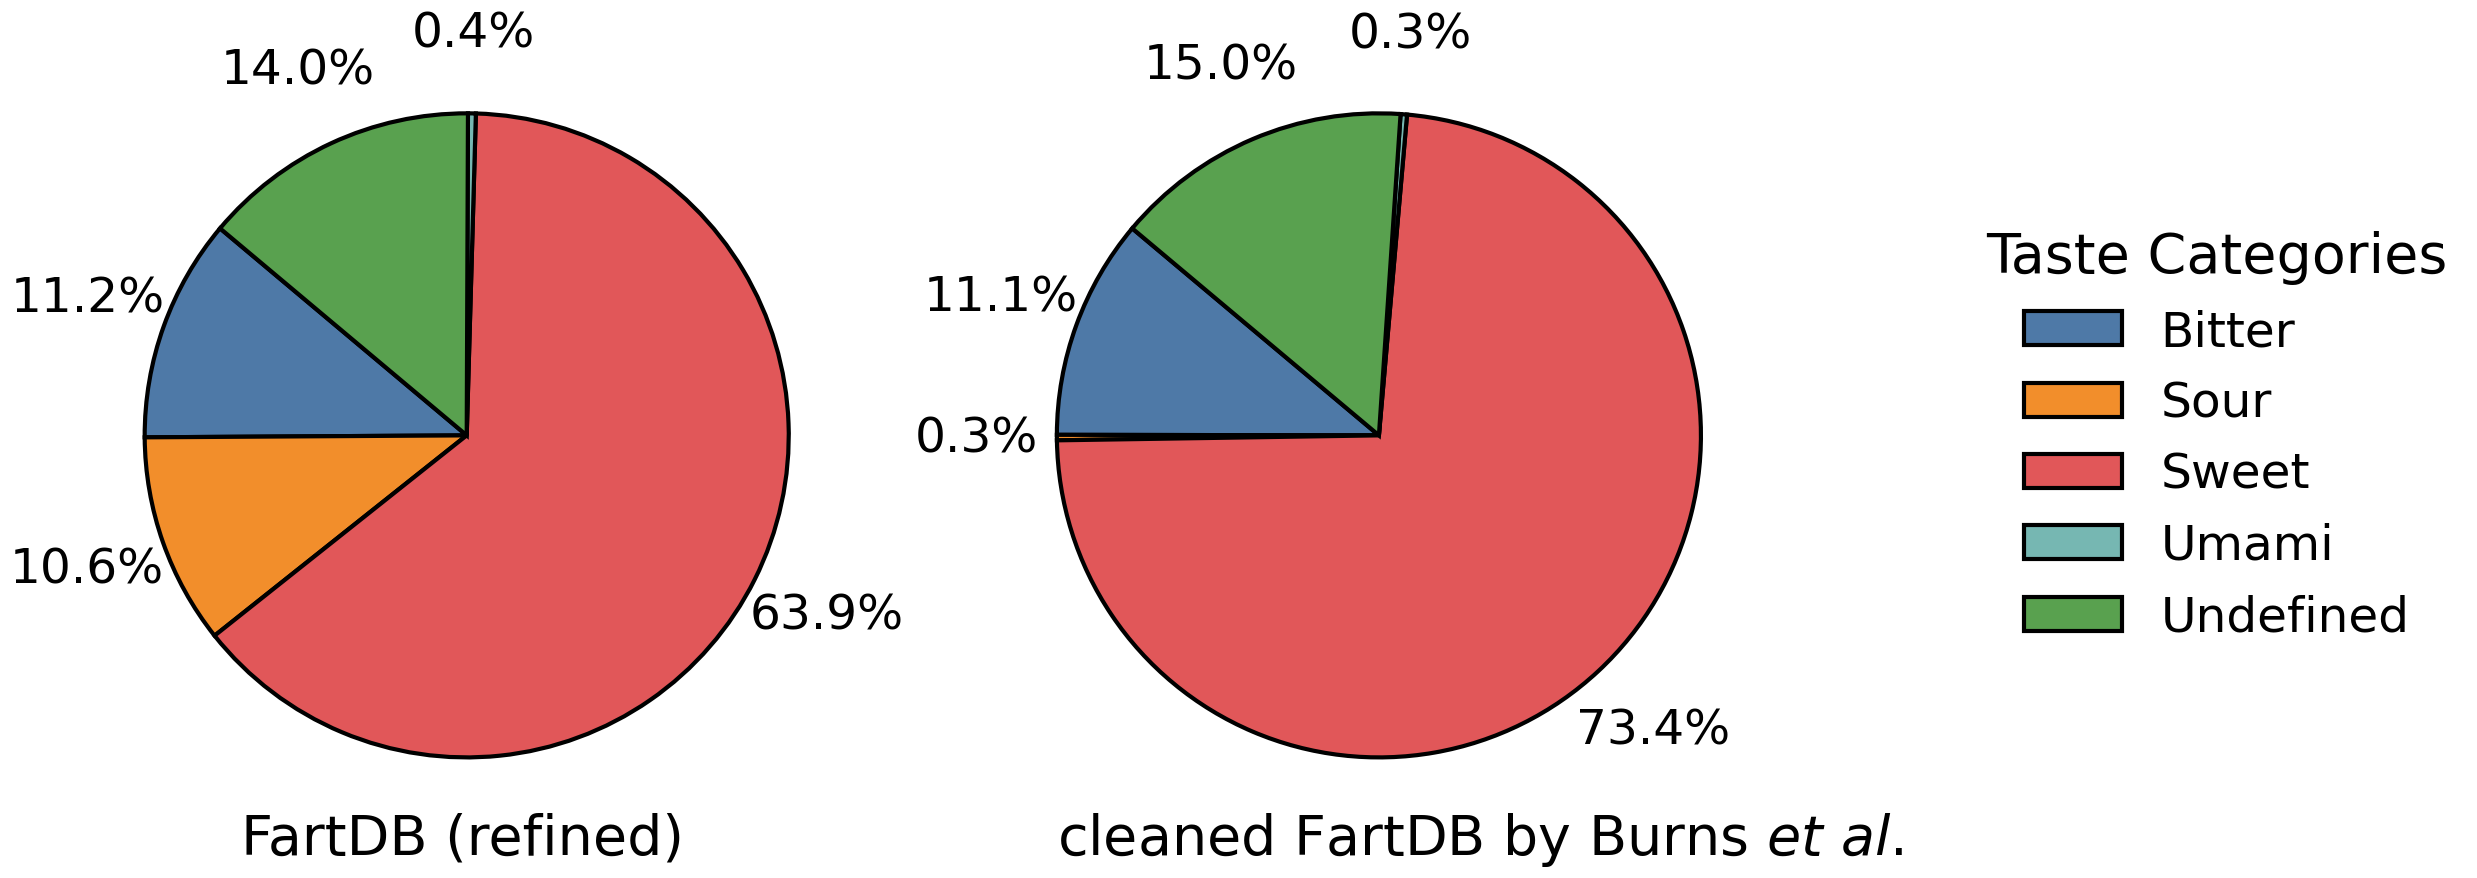

In [48]:
### Visualizing the taste distibution of fart_cleaned (left) and df (right) as pie charts

taste_frequencies = df.groupby('Canonicalized Taste').size().to_dict()
fart_taste_frequencies = fart_cleaned.groupby('Canonicalized Taste').size().to_dict()

# Normalize keys to match the taste_frequencies keys
taste_categories = {
    'Bitter': taste_frequencies.get('bitter', 0),
    'Sour': taste_frequencies.get('sour', 0),
    'Sweet': taste_frequencies.get('sweet', 0),
    'Umami': taste_frequencies.get('umami', 0),
    'Undefined': taste_frequencies.get('undefined', 0),
}

fart_taste_categories = {
    'Bitter': fart_taste_frequencies.get('bitter', 0),
    'Sour': fart_taste_frequencies.get('sour', 0),
    'Sweet': fart_taste_frequencies.get('sweet', 0),
    'Umami': fart_taste_frequencies.get('umami', 0),
    'Undefined': fart_taste_frequencies.get('undefined', 0),
}

colors = ['#4E79A7', '#F28E2B', '#E15759', '#76B7B2', '#59A14F']  # Subdued palette

# Plotting the multi figure pie chart

### Left pie chart: fart_cleaned
multifig, axes = plt.subplots(1, 2, figsize=(25, 20))
plt.sca(axes[0])
wedges, texts, autotexts = plt.pie(
    fart_taste_categories.values(),
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    pctdistance=1.25,       # Position the percentage outside the slices
    labeldistance=1.3,      # Position the labels outside the slices
    textprops={'fontsize': 50},
    wedgeprops={'edgecolor': 'black', 'linewidth':3}
)
for autotext in autotexts:
    autotext.set_fontsize(35)
    autotext.set_color('black')
plt.text(-0.7, -1.3, "FartDB (refined)", fontsize=40)

### Right pie chart: df
plt.sca(axes[1])
wedges, texts, autotexts = plt.pie(
    taste_categories.values(),
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    pctdistance=1.25,       # Position the percentage outside the slices
    labeldistance=1.3,      # Position the labels outside the slices
    textprops={'fontsize': 50},
    wedgeprops={'edgecolor': 'black', 'linewidth':3}
)
for autotext in autotexts:
    autotext.set_fontsize(35)
    autotext.set_color('black')
plt.text(-1, -1.3,r"cleaned FartDB by Burns $\it{et~al.}$", fontsize=40)


# Adding a legend
plt.legend(
    wedges,
    taste_categories.keys(),
    title="Taste Categories",
    title_fontsize=40,  # Setting the legend title font size
    loc="center left",
    bbox_to_anchor=(1.2, 0, 0.5, 1),  # Moving the legend farther to the right
    fontsize=35, 
    frameon=False
)

plt.tight_layout()
plt.savefig("proportion_of_data_sources-with-percentages.png", format='png')
plt.show()